#### Load packages, set home directory

In [13]:
import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_systems as cs
homedir="/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Annual/Bias_corrected/5km/01/"

#### Load cube with one year of data (1st December 1990 - 30th November 1991)  
Not sure what these warning messages mean...

In [121]:
homedir = "/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Annual/Bias_corrected/5km/01/"
cubes = iris.load(homedir + "bc_pr_rcp85_land-cpm_uk_5km_01_1hr_19901201-19911130.nc")

This creates 5 different cubes, not sure why

In [122]:
cubes

[<iris 'Cube' of Grid of OSGB y coordinates / (m) (projection_x_coordinate: 180; -- : 244)>,
<iris 'Cube' of projection_y_coordinate_bnds / (unknown) (-- : 244; -- : 2)>,
<iris 'Cube' of Grid of OSGB x coordinates / (m) (projection_x_coordinate: 180; -- : 244)>,
<iris 'Cube' of projection_x_coordinate_bnds / (unknown) (projection_x_coordinate: 180; -- : 2)>,
<iris 'Cube' of precipitation_amount / (kg m-2 day-1) (time: 8808; projection_x_coordinate: 180; projection_x_coordinate: 244)>]

#### Extract the precipitation cube

In [129]:
cube_precip = cubes.extract('precipitation_amount')
cube_precip = cube_precip[0]
# if isinstance(cube_precip, iris.cube.CubeList):
#     if len(cube_precip) == 1:
#         cube_precip = cube_precip[0]
#     else:
#         raise ValueError(f"Multiple cubes found for 'precipitation_amount': {cube_precip}")

#### There are two "projection_x_coordinate", try renaming one to "projection_y_coordinate"  
Not sure whether setting the bounds is necessary, or if this is the correct approach

In [130]:
# for i, c in enumerate(cube_precip.dim_coords):
#     print(i, c.name(), c.shape)
cube_precip.dim_coords[2].rename('projection_y_coordinate')

# Set bounds
# cube_precip.coord('projection_x_coordinate').bounds = test[3].data
# cube_precip.coord('projection_y_coordinate').bounds = test[1].data

#### Check the time dimension

In [131]:
# time_coord = cube_precip.coord('time')
# print(time_coord)  # Shows points, shape, and units
# print(time_coord.units) # e.g., 'days since 1970-01-01 00:00:00'

#### Assign OSGB as the coordinate system

In [132]:
print(cube_precip.coord('projection_x_coordinate').coord_system)
print(cube_precip.coord('projection_y_coordinate').coord_system)

None
TransverseMercator(latitude_of_projection_origin=49.0, longitude_of_central_meridian=-2.0, false_easting=400000.0, false_northing=-100000.0, scale_factor_at_central_meridian=0.9996012717, ellipsoid=GeogCS(semi_major_axis=6377563.396, semi_minor_axis=6356256.909))


In [133]:
# UK National Grid CRS (OSGB)
uk_osgb = cs.TransverseMercator(
    longitude_of_central_meridian=-2.0,
    latitude_of_projection_origin=49.0)

# Assign to both coords
cube_precip.coord('projection_x_coordinate').coord_system = uk_osgb
cube_precip.coord('projection_y_coordinate').coord_system = uk_osgb

#### Get just the first timeslice (1st December 1990, 00:30)

In [114]:
one_ts = cube_precip[0,:,:]
one_ts

<iris 'Cube' of precipitation_amount / (kg m-2 day-1) (projection_x_coordinate: 180; projection_y_coordinate: 244)>

#### Try plotting  
Why is this so offset from the UK?

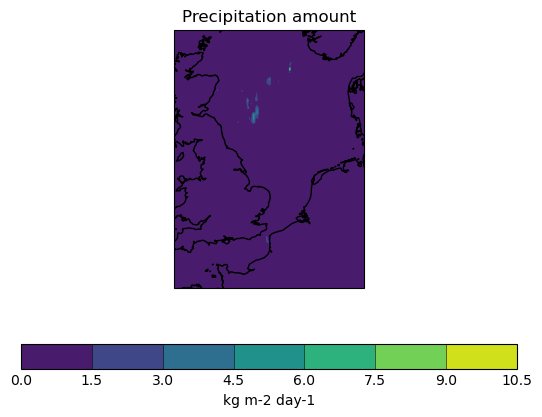

In [115]:
qplt.contourf(one_ts)  # first time slice
plt.gca().coastlines()
plt.show()

#### Look at hourly data for comparison

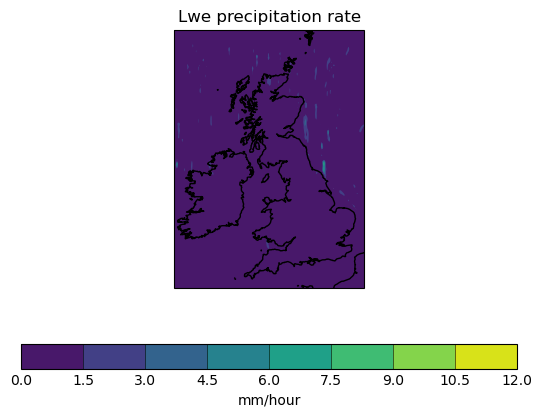

In [135]:
# New homedir
homedir="/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_01/"
# Get the equivalent dataset (for the first month in annual dataset)
hourly_orig = iris.load(homedir+ "pr_rcp85_land-cpm_uk_5km_01_1hr_19901201-19901230.nc")
# Get just the precip data
hourly_orig = hourly_orig[0]
# Get onetimestep
one_timestep_hourly_orig = hourly_orig[0,0,:,:]

# Plot
qplt.contourf(one_timestep_hourly_orig)  # first time slice
plt.gca().coastlines()
plt.show()